In [1]:
import tensorflow as tf
import tensorflow as tf
from tensorflow import keras
import os
import dataset_utils
import classifier_model
import segmentation_model
import training_utils
import combined_algorithm


Num GPUs Available:  1
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


Code to load segmentation dataset

In [2]:
BATCH_SIZE = 10
num_images_test , segmentation_test_dataset = dataset_utils.get_dataset(list(range(1,13)), './data/ams_data/processed_images/patches/test/images', './data/ams_data/processed_images/patches/test/labels', dataset_name=None, dataset_source='AMS', dataset_type='segmentation', test=True)
balanced_segmentation_test_dataset = segmentation_test_dataset.shuffle(1024).batch(BATCH_SIZE)

print(num_images_test)

138


In [3]:
classification_model_all_bands = classifier_model.build_model(12, 'simple', None)
classification_model_all_bands.load_weights('./data/model_weights/enc_16_classification_bands_all_trial1.keras')
classification_model_all_bands.compile(
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=0.0005,beta_1=0.9,beta_2=0.999,epsilon=1e-07,),
    metrics=[
      keras.metrics.BinaryAccuracy(name='accuracy'),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),
    ],
)
classification_model_all_bands.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 12)]    0         
                                                                 
 conv1 (Conv2D)              (None, 128, 128, 1)       589       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 1)      4         
 ormalization)                                                   
                                                                 
 maxpool1 (MaxPooling2D)     (None, 64, 64, 1)         0         
                                                                 
 conv3 (Conv2D)              (None, 32, 32, 2)         100       
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 2)        8         
 hNormalization)                                             

In [4]:
segmentation_model_all_bands = segmentation_model.get_trimmed_unet_model(input_channel_count=12, output_channels=1)
segmentation_model_all_bands.load_weights('./data/model_weights/enc_16_segmentation_bands_all_trial1.keras')
segmentation_model_all_bands.compile(
                optimizer= tf.keras.optimizers.Adam(learning_rate=3e-04), # tf.keras.optimizers.SGD(learning_rate=0.01), 
                loss= tf.keras.losses.BinaryCrossentropy(), # tf.keras.losses.BinaryCrossentropy(),
                metrics=[tf.keras.metrics.BinaryIoU(),],
                weighted_metrics=[
      keras.metrics.BinaryAccuracy(name='accuracy'),
      keras.metrics.Precision(name='precision'),
      keras.metrics.Recall(name='recall'),]
            )
segmentation_model_all_bands.summary()

Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                2)]                                                               
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 32  3488        ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 256, 256, 32  9248        ['conv2d[0][0]']                 
                                )                                                             

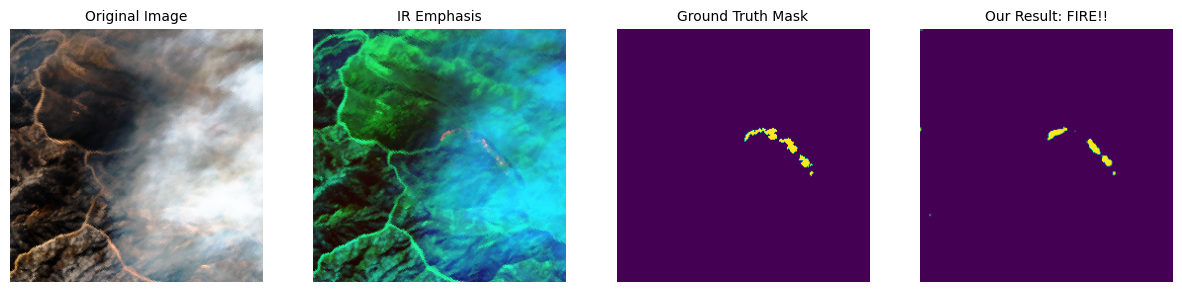

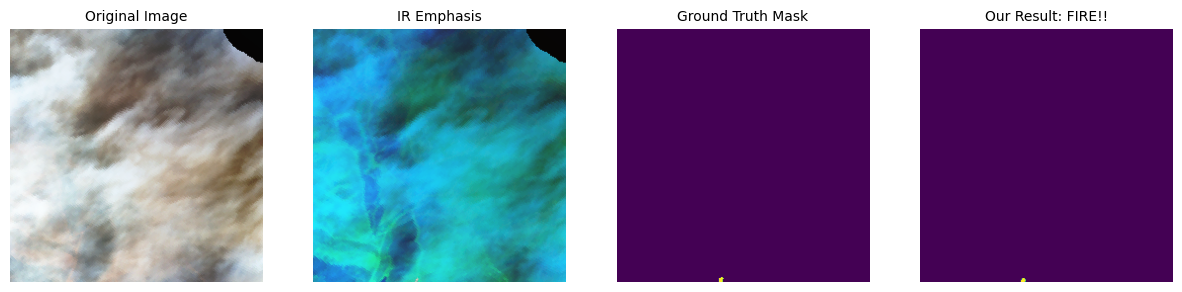

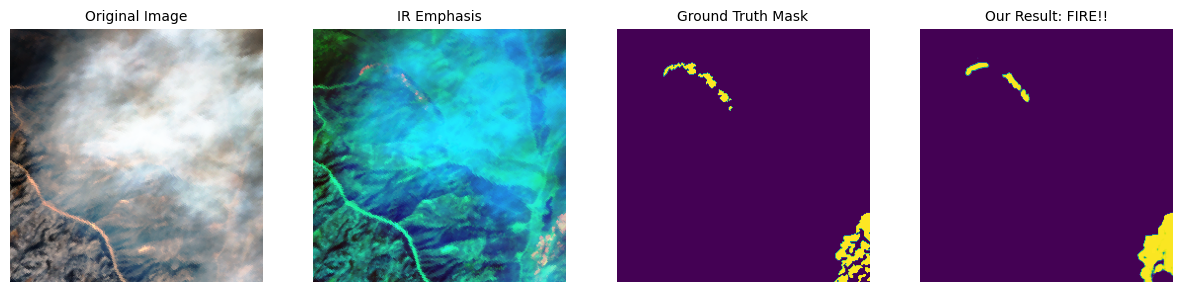

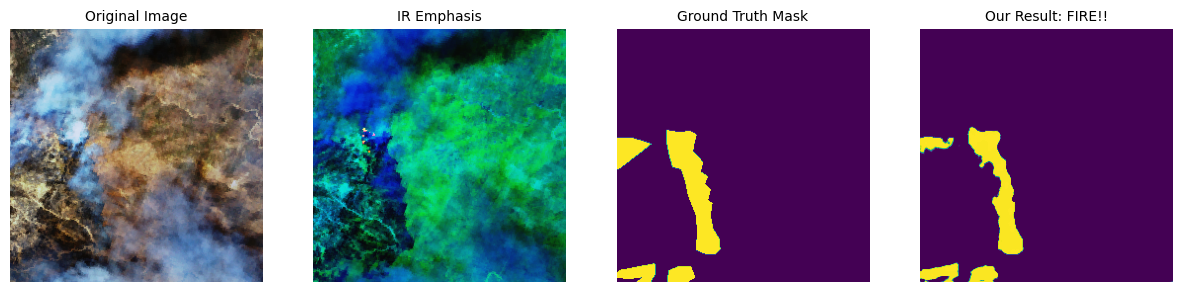

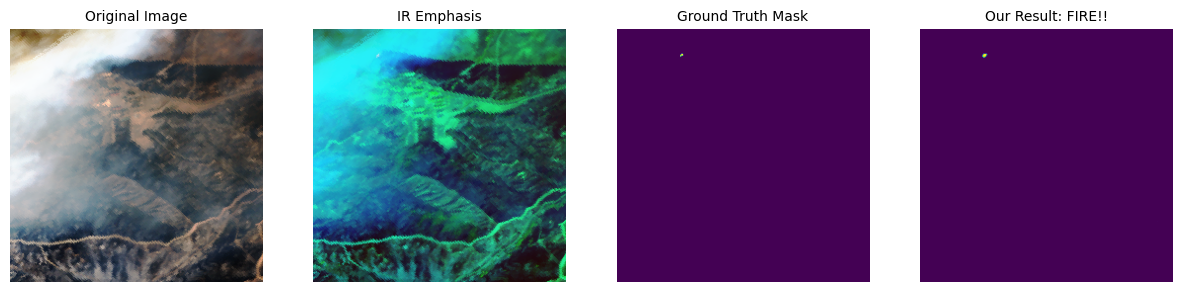

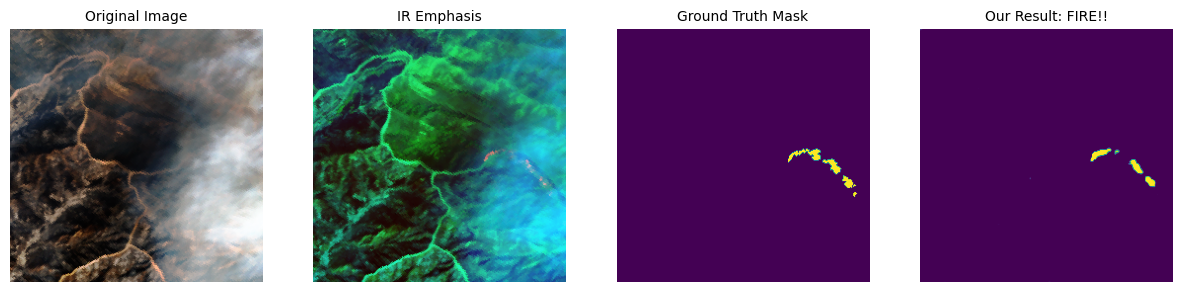

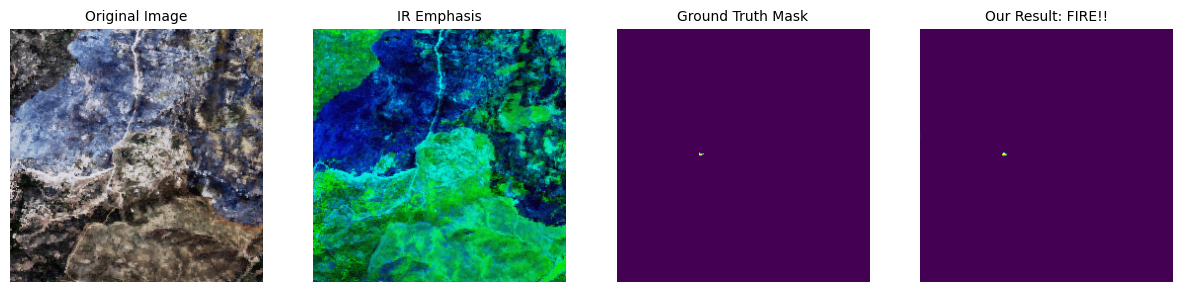

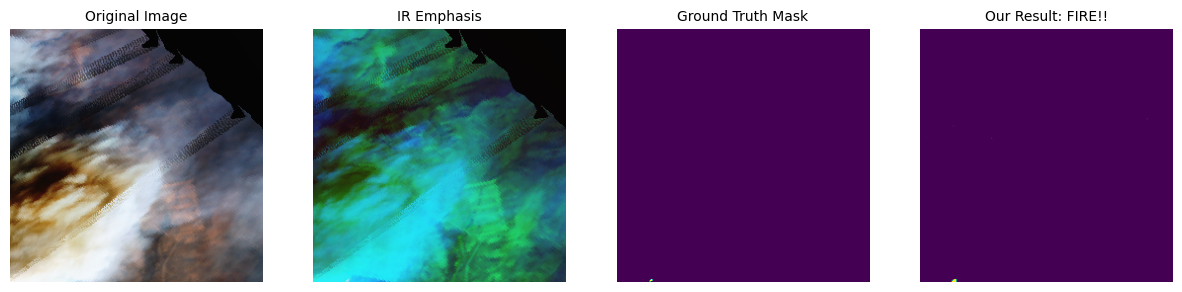

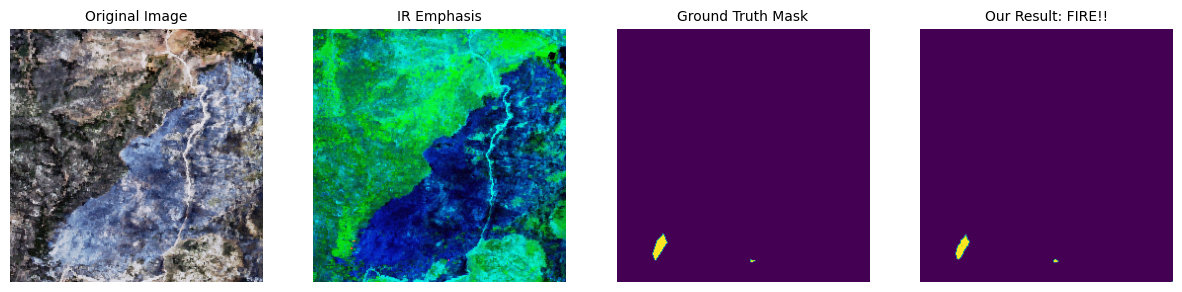

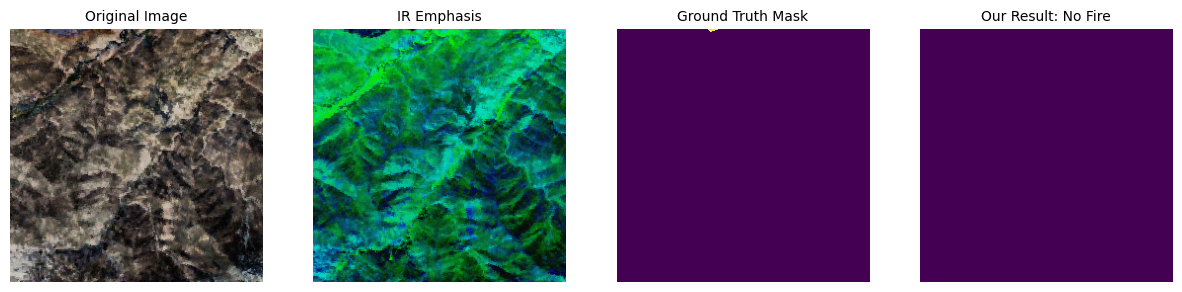

In [5]:
combined_algorithm.display_algorithm_results(balanced_segmentation_test_dataset, BATCH_SIZE, classification_model_all_bands, segmentation_model_all_bands)